In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Preprocessing & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load your dataset
df = pd.read_csv('eng.1.csv')

# Preview
df.head()

,Round,Date,Team 1,FT,Team 2
0,1,Sat Sep 12 2020,Fulham,0–3,Arsenal
1,1,Sat Sep 12 2020,Crystal Palace,1–0,Southampton
2,1,Sat Sep 12 2020,Liverpool,4–3,Leeds United
3,1,Sat Sep 12 2020,West Ham,0–2,Newcastle Utd
4,1,Sun Sep 13 2020,West Brom,0–3,Leicester City


In [3]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Round   380 non-null    int64
 1   Date    380 non-null    str  
 2   Team 1  380 non-null    str  
 3   FT      380 non-null    str  
 4   Team 2  380 non-null    str  
dtypes: int64(1), str(4)
memory usage: 29.9 KB


Round     0
Date      0
Team 1    0
FT        0
Team 2    0
dtype: int64

In [4]:
# Example: Drop missing values (or handle differently if needed)
df = df.dropna()

# If categorical columns exist → encode them
df = pd.get_dummies(df)

df.head()

,Round,Date_Fri Apr 09 2021,Date_Fri Apr 16 2021,Date_Fri Apr 23 2021,Date_Fri Apr 30 2021,Date_Fri Dec 11 2020,Date_Fri Feb 19 2021,Date_Fri Jan 01 2021,Date_Fri Mar 12 2021,Date_Fri Mar 19 2021,Date_Fri May 07 2021,Date_Fri May 14 2021,Date_Fri Nov 06 2020,Date_Fri Nov 27 2020,Date_Fri Oct 23 2020,Date_Fri Oct 30 2020,Date_Mon Apr 05 2021,Date_Mon Apr 12 2021,Date_Mon Apr 19 2021,Date_Mon Apr 26 2021,Date_Mon Dec 07 2020,Date_Mon Dec 21 2020,Date_Mon Dec 28 2020,Date_Mon Feb 08 2021,Date_Mon Feb 15 2021,Date_Mon Feb 22 2021,Date_Mon Jan 04 2021,Date_Mon Jan 18 2021,Date_Mon Mar 01 2021,Date_Mon Mar 08 2021,Date_Mon Mar 15 2021,Date_Mon May 03 2021,Date_Mon May 10 2021,Date_Mon Nov 02 2020,Date_Mon Nov 23 2020,Date_Mon Nov 30 2020,Date_Mon Oct 19 2020,Date_Mon Oct 26 2020,Date_Mon Sep 14 2020,Date_Mon Sep 21 2020,...,FT_2–0,FT_2–1,FT_2–2,FT_2–3,FT_2–4,FT_2–5,FT_3–0,FT_3–1,FT_3–2,FT_3–3,FT_3–4,FT_4–0,FT_4–1,FT_4–2,FT_4–3,FT_5–0,FT_5–2,FT_6–2,FT_7–2,FT_9–0,Team 2_Arsenal,Team 2_Aston Villa,Team 2_Brighton,Team 2_Burnley,Team 2_Chelsea,Team 2_Crystal Palace,Team 2_Everton,Team 2_Fulham,Team 2_Leeds United,Team 2_Leicester City,Team 2_Liverpool,Team 2_Manchester City,Team 2_Manchester Utd,Team 2_Newcastle Utd,Team 2_Sheffield Utd,Team 2_Southampton,Team 2_Tottenham,Team 2_West Brom,Team 2_West Ham,Team 2_Wolves
0,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
3,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [6]:
print(df.columns.tolist())

['Round', 'Date_Fri Apr 09 2021', 'Date_Fri Apr 16 2021', 'Date_Fri Apr 23 2021', 'Date_Fri Apr 30 2021', 'Date_Fri Dec 11 2020', 'Date_Fri Feb 19 2021', 'Date_Fri Jan 01 2021', 'Date_Fri Mar 12 2021', 'Date_Fri Mar 19 2021', 'Date_Fri May 07 2021', 'Date_Fri May 14 2021', 'Date_Fri Nov 06 2020', 'Date_Fri Nov 27 2020', 'Date_Fri Oct 23 2020', 'Date_Fri Oct 30 2020', 'Date_Mon Apr 05 2021', 'Date_Mon Apr 12 2021', 'Date_Mon Apr 19 2021', 'Date_Mon Apr 26 2021', 'Date_Mon Dec 07 2020', 'Date_Mon Dec 21 2020', 'Date_Mon Dec 28 2020', 'Date_Mon Feb 08 2021', 'Date_Mon Feb 15 2021', 'Date_Mon Feb 22 2021', 'Date_Mon Jan 04 2021', 'Date_Mon Jan 18 2021', 'Date_Mon Mar 01 2021', 'Date_Mon Mar 08 2021', 'Date_Mon Mar 15 2021', 'Date_Mon May 03 2021', 'Date_Mon May 10 2021', 'Date_Mon Nov 02 2020', 'Date_Mon Nov 23 2020', 'Date_Mon Nov 30 2020', 'Date_Mon Oct 19 2020', 'Date_Mon Oct 26 2020', 'Date_Mon Sep 14 2020', 'Date_Mon Sep 21 2020', 'Date_Mon Sep 28 2020', 'Date_Sat Apr 03 2021', 'Date_

In [8]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Example dataset
df = pd.DataFrame({
    "feature1": [1, 2, 3, 4],
    "feature2": [5, 6, 7, 8],
    "target": [0, 1, 0, 1]
})

X = df[["feature1", "feature2"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
print("Train:\n", y_train.value_counts())
print("\nTest:\n", y_test.value_counts())

Train:
 target
0    2
1    1
Name: count, dtype: int64

Test:
 target
1    1
Name: count, dtype: int64


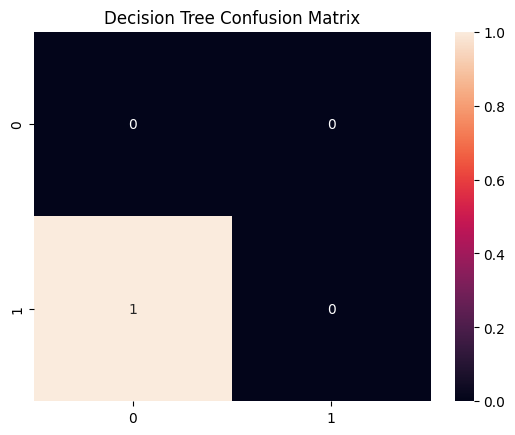

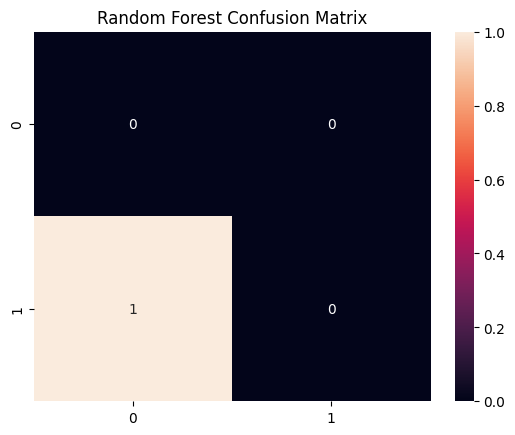

In [13]:
# Decision Tree
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

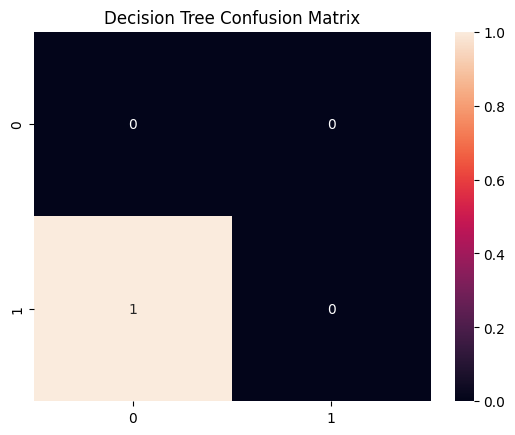

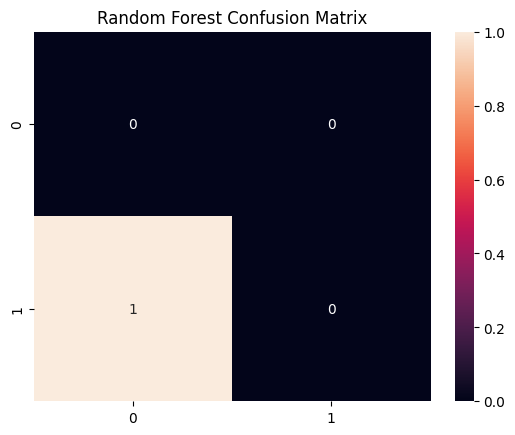

In [14]:
# Decision Tree
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

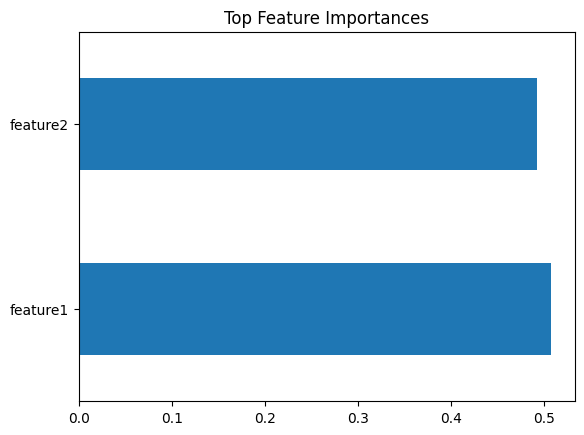

In [15]:
importances = rf_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')
plt.title("Top Feature Importances")
plt.show()